<a href="https://colab.research.google.com/github/WajeehaAslam/Ann_lab/blob/main/HUMAN_ACTION_RECOGNITION(CNN%2BLSTM_)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
%%capture

!pip install pafy youtube-dl moviepy

In [11]:
import os
import cv2
import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt


from moviepy.editor import *
%matplotlib inline


from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

seed to get consistent results on every execution and control the randomness/restrict the randomness and
assign it to certain constant



In [12]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [17]:
# Discard the output of this cell.
%%capture

# Downlaod the UCF50 Dataset
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF50.rar

#Extract the Dataset
!unrar x UCF50.rar

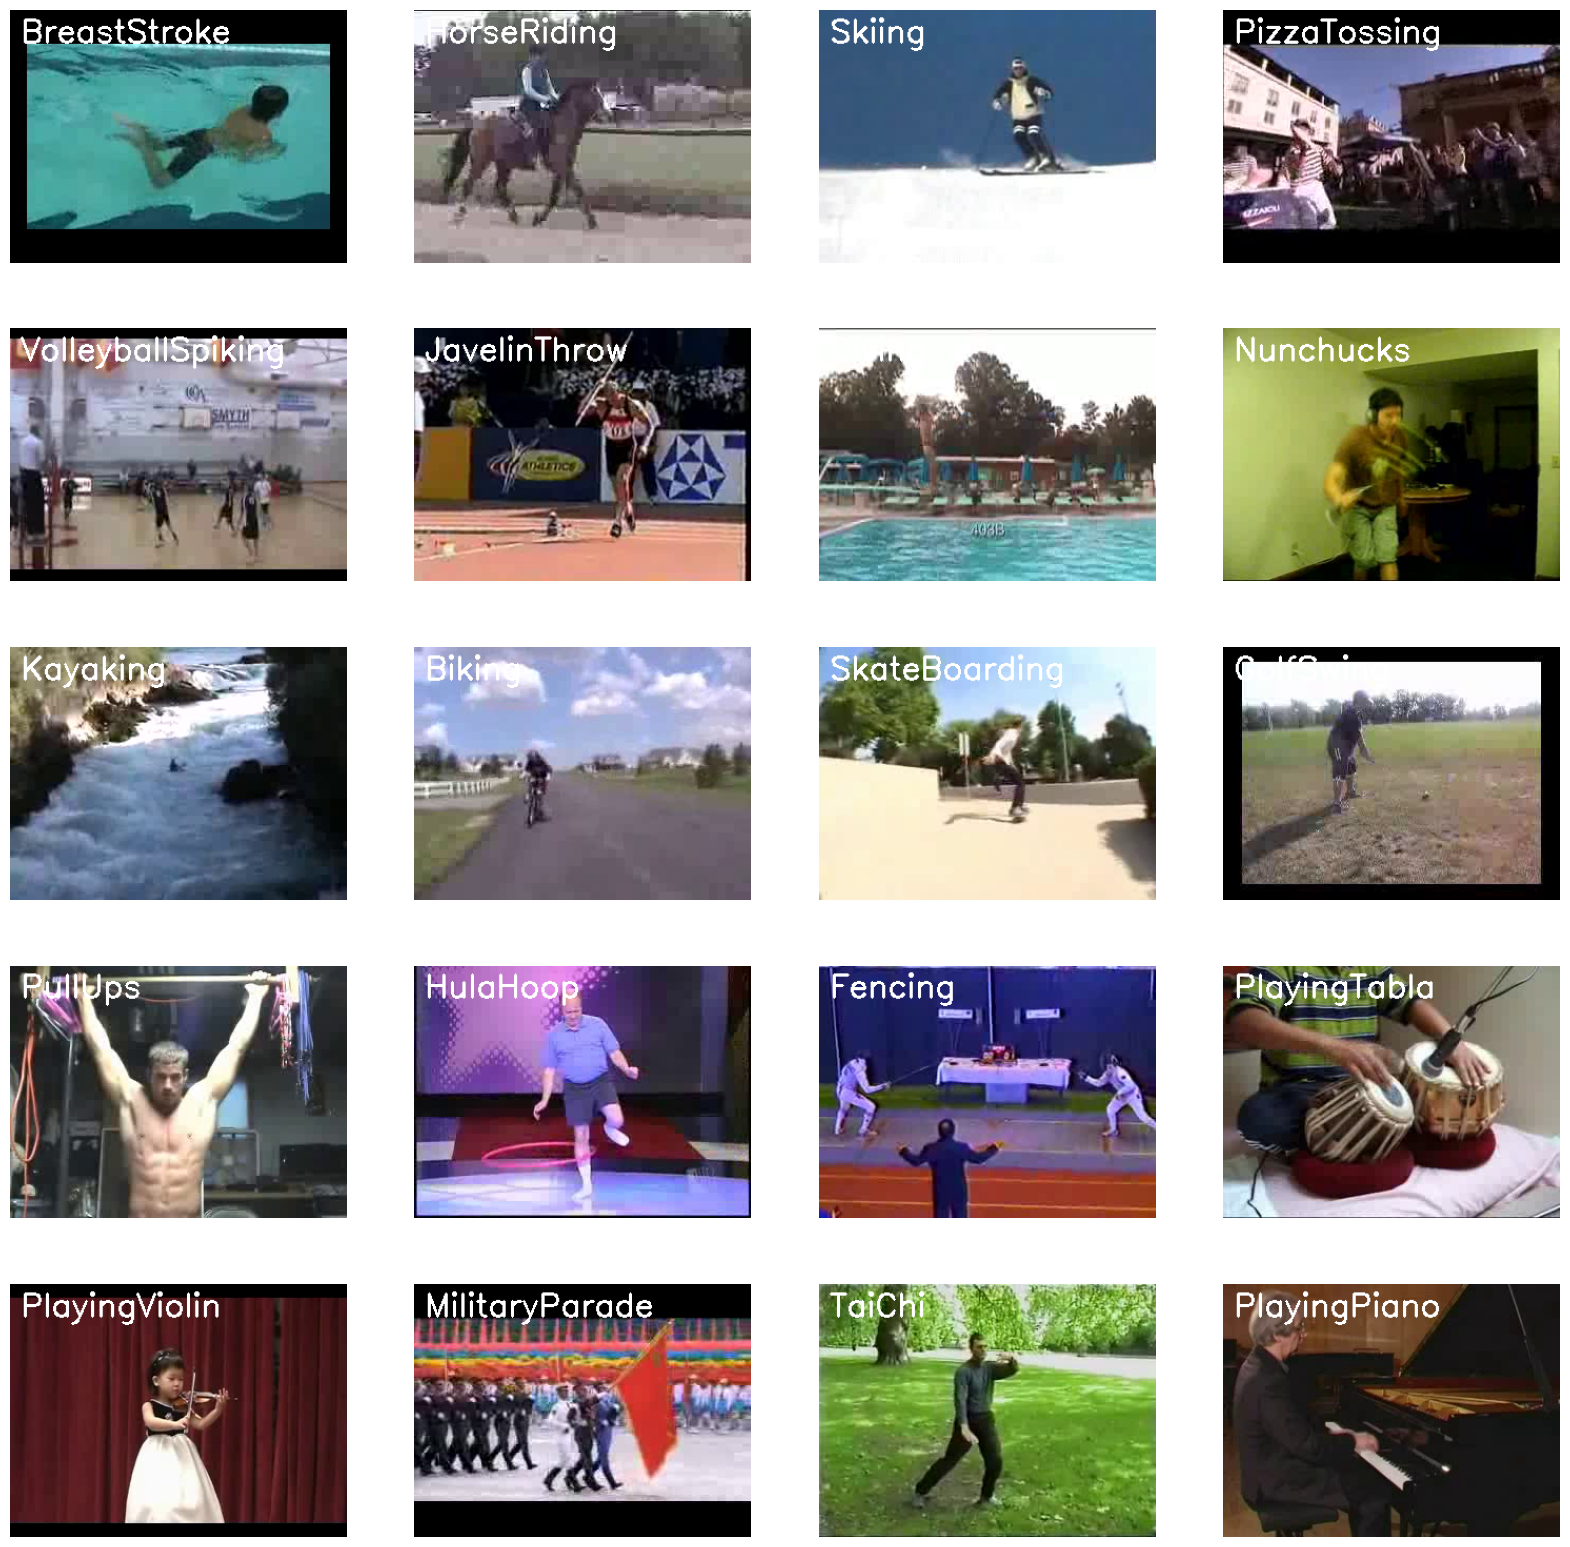

In [21]:
plt.figure(figsize =(20,20))


all_classes_names = os.listdir('UCF50')


random_range = random.sample(range(len(all_classes_names)),20)


for counter ,random_index in enumerate(random_range,1):


  selected_class_Name = all_classes_names[random_index]

  video_files_names_list = os.listdir(f'UCF50/{selected_class_Name}')

  selected_video_file_name =random.choice(video_files_names_list)


  video_reader = cv2.VideoCapture(f'UCF50/{selected_class_Name}/{selected_video_file_name}')


  _, bgr_frame = video_reader.read()


  video_reader.release()

  rgb_frame = cv2.cvtColor(bgr_frame,cv2.COLOR_BGR2RGB)

  cv2.putText(rgb_frame,selected_class_Name,(10,30),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2)

  plt.subplot(5,4,counter);plt.imshow(rgb_frame);plt.axis('off')














In [22]:
IMAGE_HEIGHT ,IMAGE_WIDTH = 64,64

SEQUENCE_LENGTH =20

DATASET_DIR ="UCF50"

CLASSES_LIST =["WalkingWithDog","TaiChi","Swing","HorseRace"]

